# Fabric Defect Classification — Data Preprocessing

**Notebook 02** of the fabric defect classification pipeline.

Notebook 01 explored the raw data and found several problems. This notebook fixes them and produces a clean dataset ready for training.

**What Notebook 01 told us:**

- The download contains 3,067 files, but only **2,758 are genuinely different images**.
- Three classes contain grayscale **processed copies** made from originals. These add no new information, and because they exist in only three classes they give the model a shortcut.
- There are **17 exact duplicates** saved under different names, and **40 images** in near-identical clusters caused by file copying.
- Classes are **severely imbalanced** — "defect free" is 60.4% of the data, while "Vertical" and "horizontal" are about 1.2% each. The largest class is 52 times the smallest.
- Image sizes vary hugely, and files come in a mix of JPEG and PNG, colour and grayscale.
- **No fabric roll or batch information exists**, so we cannot split the data by production batch.

**What this notebook does:**

1. Removes every kind of duplicate
2. Checks whether image size gives away the class
3. Converts all images to one consistent colour format and size
4. Splits the data using cross-validation
5. Calculates weights to correct the class imbalance
6. Saves everything for Notebook 03

## 1. Setup

**What:** Load the libraries and locate the dataset.

**Why:** Each notebook runs on its own, so we reload the same dataset that Notebook 01 used. `OUT_DIR` is where the cleaned images will be written — change it if you are not running on Kaggle.

In [ ]:
import hashlib
import json
import os
import random
import shutil
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from sklearn.model_selection import StratifiedKFold

# ---------------- Configuration ----------------
IMG_SIZE = 224
N_FOLDS = 5
SEED = 42

# OUT_DIR is the folder the cleaned images are written to.
# Leave as None to choose automatically, or set a path yourself.
OUT_DIR = None
# -----------------------------------------------

random.seed(SEED)

# Locate the raw dataset
ds2 = "/kaggle/input/multi-class-fabric-defect-detection-dataset/Dataset"
if not os.path.exists(ds2):
    import kagglehub
    ds2 = os.path.join(
        kagglehub.dataset_download("ziya07/multi-class-fabric-defect-detection-dataset"),
        "Dataset",
    )

# Resolve the working folder if it was left automatic
if OUT_DIR is None:
    if Path("/content").exists():
        OUT_DIR = Path("/content/data/processed")        # Colab local disk (fast)
    elif Path("/kaggle/working").exists():
        OUT_DIR = Path("/kaggle/working/processed")      # Kaggle
    else:
        OUT_DIR = Path("data/processed")                 # local machine
OUT_DIR = Path(OUT_DIR)

class_names = sorted(os.listdir(ds2))

print("Raw dataset :", ds2)
print("Output      :", OUT_DIR)
print("Classes     :", class_names)

100%|██████████| 2.10G/2.10G [00:30<00:00, 74.7MB/s]

Extracting files...


Raw dataset : /root/.cache/kagglehub/datasets/ziya07/multi-class-fabric-defect-detection-dataset/versions/3/Dataset
Output      : /content/data/processed
Classes     : ['Broken stitch', 'Needle mark', 'Pinched fabric', 'Vertical', 'defect free', 'hole', 'horizontal', 'lines', 'stain']


## 2. Remove the Duplicates

**What:** Build the final list of images to keep, removing all three kinds of duplicate found in Notebook 01.

**Why:** This is the most important cleaning step. If two files trace back to the same original photograph and end up on opposite sides of a train/test split, the model is being graded on a picture it has already memorised — the score would look excellent and mean nothing.

Notebook 01 found three separate kinds of duplicate, and each needs its own detection method:

| Kind | What it is | How we detect it |
|---|---|---|
| **Processed derivative** | A grayscale version made from an original | The `_processed` ending in the filename |
| **Exact duplicate** | The identical file under a different name | An MD5 fingerprint of the file's bytes |
| **Near-duplicate** | The same picture re-saved, so the bytes differ | A difference hash comparing how the image looks |

We apply them in that order, keeping the first image we meet from each group and dropping the rest.

In [ ]:
def dhash(path, size=16):
    """Fingerprint based on appearance: compares each pixel with its right neighbour."""
    with Image.open(path) as img:
        small = img.convert("L").resize((size + 1, size), Image.BILINEAR)
    px = list(small.getdata())
    bits = []
    for row in range(size):
        for col in range(size):
            left = px[row * (size + 1) + col]
            right = px[row * (size + 1) + col + 1]
            bits.append("1" if left > right else "0")
    return "".join(bits)


# --- Step 1: drop the processed derivatives -------------------------------
candidates = [
    (cls, p)
    for cls in class_names
    for p in sorted((Path(ds2) / cls).glob("*"))
    if "_processed" not in p.name
]
raw_total = sum(len(list((Path(ds2) / cls).glob("*"))) for cls in class_names)
print(f"Raw files                     : {raw_total}")
print(f"After removing _processed     : {len(candidates)}")

# --- Step 2: drop exact duplicates ---------------------------------------
seen_md5, after_exact = set(), []
for cls, p in candidates:
    h = hashlib.md5(p.read_bytes()).hexdigest()
    if h in seen_md5:
        continue
    seen_md5.add(h)
    after_exact.append((cls, p))
print(f"After removing exact copies   : {len(after_exact)}")

# --- Step 3: drop near-duplicates (within each class) --------------------
seen_dhash, keep = set(), []
for cls, p in after_exact:
    key = (cls, dhash(p))
    if key in seen_dhash:
        continue
    seen_dhash.add(key)
    keep.append((cls, p))
print(f"After removing near-duplicates: {len(keep)}")
print(f"\nRemoved in total: {raw_total - len(keep)} files")

Raw files                     : 3067
After removing _processed     : 2758
After removing exact copies   : 2741
After removing near-duplicates: 2737

Removed in total: 330 files


**Observations:** The three passes removed **330 files in total**, leaving **2,737 genuinely different images** out of the original 3,067.

| Stage | Remaining | Removed |
|---|---:|---:|
| Raw files | 3,067 | — |
| After removing `_processed` | 2,758 | 309 |
| After removing exact copies | 2,741 | 17 |
| After removing near-duplicates | 2,737 | 4 |

The near-duplicate pass removed only 4 images, even though Notebook 01 found 19 clusters covering 40 images. That is not a contradiction. The exact-duplicate pass ran first and had already caught most of them, because the `- Copy` and `(1)` files turned out to be byte-identical rather than merely similar. The two checks overlap, and running them in this order avoids removing the same file twice.

In [ ]:
final_counts = Counter(cls for cls, _ in keep)
total = len(keep)

print(f"{'Class':20s} {'Images':>7s} {'Share':>8s}")
for cls, n in sorted(final_counts.items(), key=lambda x: -x[1]):
    print(f"{cls:20s} {n:7d} {n/total:7.1%}")

print(f"\nTotal: {total}")
print(f"Imbalance ratio: {max(final_counts.values()) / min(final_counts.values()):.0f}:1")

Class                 Images    Share
defect free             1663   60.8%
stain                    398   14.5%
lines                    146    5.3%
hole                     141    5.2%
Broken stitch            112    4.1%
Needle mark              108    3.9%
Pinched fabric           108    3.9%
horizontal                34    1.2%
Vertical                  27    1.0%

Total: 2737
Imbalance ratio: 62:1


**Observations:** The cleaned dataset holds **2,737 images**, and the imbalance is **worse** than Notebook 01 predicted:

| Class | Images | Share |
|---|---:|---:|
| defect free | 1,663 | 60.8% |
| stain | 398 | 14.5% |
| lines | 146 | 5.3% |
| hole | 141 | 5.2% |
| Broken stitch | 112 | 4.1% |
| Needle mark | 108 | 3.9% |
| Pinched fabric | 108 | 3.9% |
| horizontal | 34 | 1.2% |
| Vertical | 27 | 1.0% |

"Vertical" has fallen to **27 images** — fewer than the 32 Notebook 01 estimated, because comparing file contents caught 5 duplicates that inspecting filenames alone had missed. The imbalance ratio is now **62:1**, up from the 52:1 predicted earlier.

This strengthens the case for cross-validation rather than weakening it. With 27 images, a single 15% test split would leave "Vertical" with roughly **4 test images** — a recall figure built from 4 images moves in 25-point jumps and cannot be reported honestly.

## 3. Does Image Size Give Away the Class?

**What:** List the image sizes and colour formats used by each class.

**Why:** This decides how we resize, and it matters more than it sounds.

Notebook 01 found only 13 different image sizes across the whole dataset, and that the data came from several separate collections. If each collection used its own camera, then each class may have its own characteristic image size — and size would quietly become a clue to the answer.

That would rule out one popular resizing method. **Letterboxing** shrinks an image to fit and fills the leftover space with black bars, which keeps the original proportions intact. But if proportions differ by class, those black bars would tell the model which class it is looking at, without it ever examining the fabric.

So we check first, then choose.

In [ ]:
print(f"{'Class':16s} {'Colour formats':26s} {'Most common sizes'}")
print("-" * 90)
for cls in class_names:
    modes, sizes = Counter(), Counter()
    for c, p in keep:
        if c != cls:
            continue
        with Image.open(p) as img:
            modes[img.mode] += 1
            sizes[img.size] += 1
    top = ", ".join(f"{w}x{h} ({n})" for (w, h), n in sizes.most_common(3))
    print(f"{cls:16s} {str(dict(modes)):26s} {top}")

Class            Colour formats             Most common sizes
------------------------------------------------------------------------------------------
Broken stitch    {'RGB': 112}               224x224 (112)
Needle mark      {'RGB': 108}               224x224 (108)
Pinched fabric   {'RGB': 108}               224x224 (108)
Vertical         {'RGB': 23, 'L': 4}        640x360 (23), 219x264 (1), 221x264 (1)
defect free      {'L': 189, 'LA': 20, 'RGB': 1454} 2446x1000 (1454), 4096x256 (141), 1984x1488 (49)
hole             {'RGB': 141}               1280x720 (80), 640x360 (46), 4608x3456 (15)
horizontal       {'RGB': 34}                640x360 (34)
lines            {'RGB': 146}               1280x720 (142), 4608x3456 (4)
stain            {'L': 398}                 1984x1488 (256), 1488x1984 (142)


**Observations:** **Image size gives the class away — clearly and strongly.**

| Class | Colour formats | Most common sizes |
|---|---|---|
| Broken stitch | all RGB | **224×224** (all 112) |
| Needle mark | all RGB | **224×224** (all 108) |
| Pinched fabric | all RGB | **224×224** (all 108) |
| Vertical | 23 RGB, 4 L | 640×360 |
| horizontal | all RGB | 640×360 (all 34) |
| hole | all RGB | 1280×720, 640×360, 4608×3456 |
| lines | all RGB | 1280×720 |
| stain | **all 398 grayscale (L)** | 1984×1488, 1488×1984 |
| defect free | 1454 RGB, 189 L, 20 LA | 2446×1000, 4096×256 |

Three classes — "Broken stitch", "Needle mark" and "Pinched fabric" — are **already exactly 224×224 in every single image**, and no other class contains a 224×224 image at all. "defect free" is dominated by 2446×1000, a size nothing else uses. Knowing only an image's dimensions would let you guess its class correctly a large share of the time.

This settles the resizing decision, and shows the original plan would have been a mistake. **Letterbox padding would have leaked the answer**: it keeps the original proportions by adding black bars, so the shape of those bars would itself have identified the source collection, and therefore the class. Resizing directly to a square throws that information away completely.

**A second leak that resizing does not fix.** Colour format is class-linked too: all 398 "stain" images are stored as single-channel grayscale, while most other classes are full colour. Converting everything to RGB makes every image three-channel, but a grayscale image converted to RGB is still visibly colourless — so a model could learn "no colour variation means stain" without ever examining the fabric.

We record this as a limitation rather than solving it here. Notebook 03 reduces it by randomly converting training images to grayscale, which makes the cue unreliable. A stronger option would be to convert *every* image to grayscale, removing colour as a signal entirely — reasonable given that the one class where colour would matter most is already stored without it.

## 4. Standardise Every Image

**What:** Convert each image to colour format and resize it to 224×224.

**Why:** Notebook 01 found the images arrive in inconsistent forms — some JPEG and some PNG, some full colour and some grayscale, in 13 different sizes. A neural network needs every input to be identical in shape and channel count.

Converting to `RGB` handles all of it at once: grayscale images get their single brightness value copied into three colour channels, and PNG transparency is discarded. Every image ends up as 224×224 with three channels, regardless of how it started.

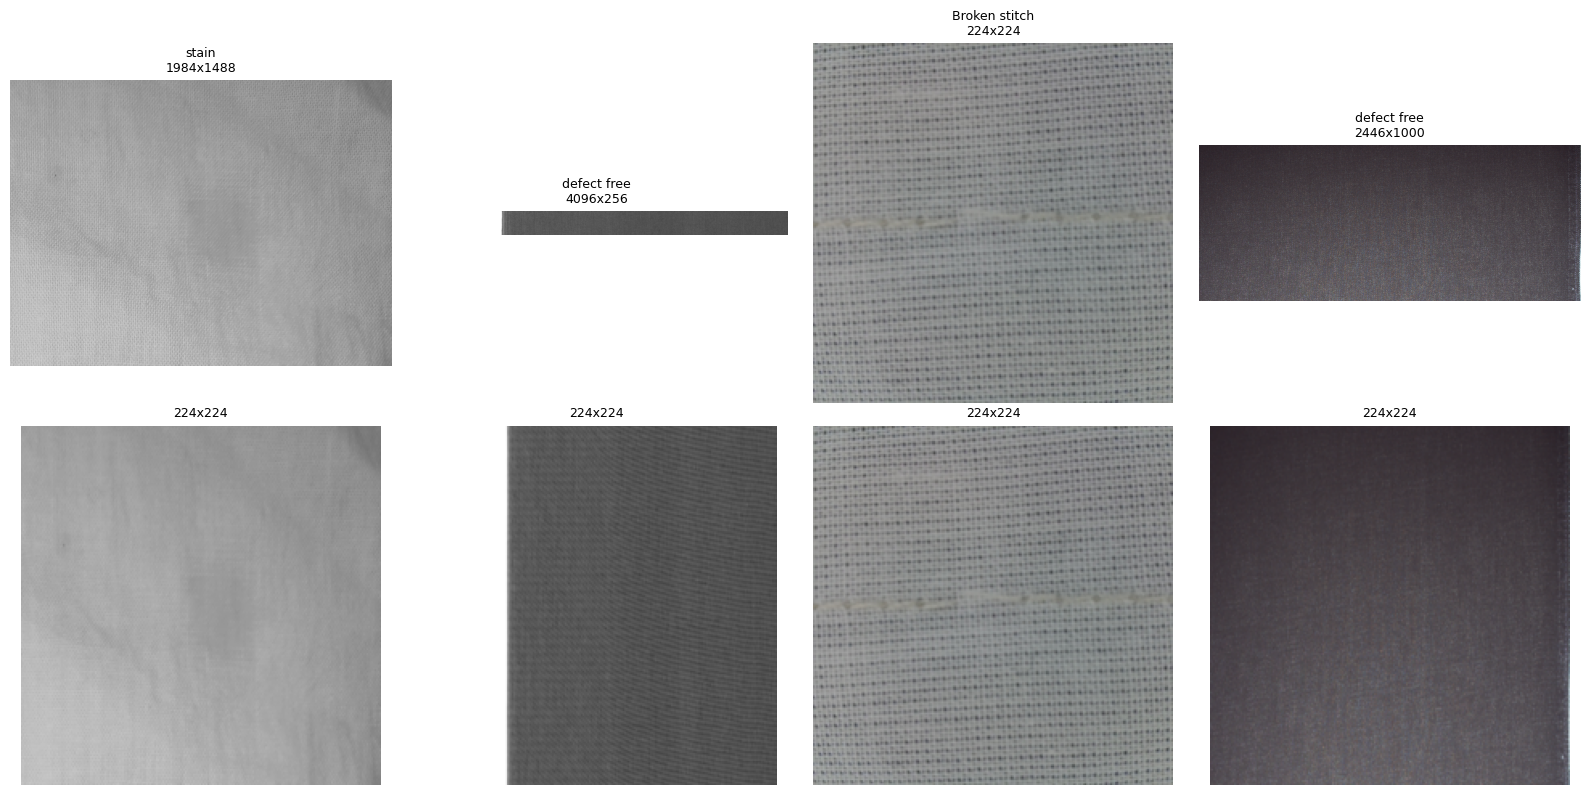

In [ ]:
def preprocess(path, size=IMG_SIZE):
    """Convert to 3-channel colour and resize to a fixed square."""
    with Image.open(path) as img:
        return img.convert("RGB").resize((size, size), Image.BILINEAR)


# Visual check: a few images before and after
samples = random.sample(keep, 4)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col, (cls, p) in enumerate(samples):
    with Image.open(p) as img:
        axes[0, col].imshow(img.convert("RGB"))
        axes[0, col].set_title(f"{cls}\n{img.size[0]}x{img.size[1]}", fontsize=9)
    axes[1, col].imshow(preprocess(p))
    axes[1, col].set_title(f"{IMG_SIZE}x{IMG_SIZE}", fontsize=9)
    axes[0, col].axis("off")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("original")
axes[1, 0].set_ylabel("processed")
plt.tight_layout()
plt.show()

**Observations:** The defects stay clearly visible after resizing. Distortion is greatest for the widest source images — "defect free" at 2446×1000 is compressed to roughly a quarter of its original width — but this changes proportions, not direction. A vertical line in the original is still vertical afterwards, so the orientation-based classes ("Vertical", "horizontal", "lines") are unaffected in the way that matters.

Every image now leaves this step as 224×224 in three-channel colour, regardless of whether it began as a 4608×3456 colour photograph or a 640×360 grayscale one.

## 5. Split the Data with Cross-Validation

**What:** Divide the images into 5 folds, keeping each class's proportions the same in every fold.

**Why:** The obvious approach would be a single split — say 70% train, 15% validation, 15% test. That fails here because of how small the rare classes are.

"Vertical" has about 32 images. A 15% test share would give it roughly **5 test images**. Each one would then be worth 20 percentage points of recall, so the score would jump around wildly depending on which 5 images happened to land there. That is not a measurement.

**Cross-validation** solves this. We split into 5 equal folds and train 5 times, each time holding out a different fold for testing. Every image gets tested exactly once, so "Vertical" ends up with all 32 predictions instead of 5. This directly supports reporting per-class recall for the rare defects.

We use `StratifiedKFold`, which keeps each class's share the same in every fold — without it, a fold could easily end up with no "Vertical" images at all.

**A note on grouping:** normally we would also make sure related images (same fabric roll, same photo session) stay together in one fold. Notebook 01 searched for that grouping twice — in the filenames, and by finding visually similar images — and found none. Since every duplicate has now been removed, each remaining image is independent, so a plain stratified split is correct here.

In [ ]:
paths = [p for _, p in keep]
labels = [cls for cls, _ in keep]

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_of = {}
for fold_idx, (_, test_idx) in enumerate(skf.split(paths, labels)):
    for i in test_idx:
        fold_of[i] = fold_idx

print(f"{'Class':16s} " + " ".join(f"{'fold'+str(f):>7s}" for f in range(N_FOLDS)) + f" {'total':>7s}")
print("-" * 70)
for cls in class_names:
    row = [sum(1 for i, l in enumerate(labels) if l == cls and fold_of[i] == f)
           for f in range(N_FOLDS)]
    print(f"{cls:16s} " + " ".join(f"{n:7d}" for n in row) + f" {sum(row):7d}")

Class              fold0   fold1   fold2   fold3   fold4   total
----------------------------------------------------------------------
Broken stitch         23      23      22      22      22     112
Needle mark           21      21      22      22      22     108
Pinched fabric        22      22      22      21      21     108
Vertical               5       5       5       6       6      27
defect free          333     333     333     332     332    1663
hole                  28      28      28      29      28     141
horizontal             7       7       7       6       7      34
lines                 29      29      29      30      29     146
stain                 80      80      79      79      80     398


**Observations:** Every class appears in every fold — which is exactly what stratification is for. Without it, a fold could easily have ended up with no "Vertical" images at all, making that fold impossible to score.

The rare classes are spread as evenly as their small counts allow: "Vertical" gets 5–6 images per fold, "horizontal" 6–7.

The benefit is clearest for "Vertical". A single 70/15/15 split would have given it about **4 test images**; across five folds, all **27** are tested exactly once. That is the difference between a recall figure that jumps 25 points depending on a single image, and one that can be reported with a straight face.

## 6. Weight the Classes

**What:** Give each class a weight based on how rare it is.

**Why:** With "defect free" making up 60% of the data and "Vertical" only 1.2%, a model can score 60% accuracy by always answering "defect free" — Notebook 01 measured exactly this. Left uncorrected, training pushes the model straight towards that useless shortcut, because ignoring the rare classes barely affects the overall error.

Class weights fix this by changing the cost of a mistake. Getting a "Vertical" image wrong becomes far more expensive than getting a "defect free" image wrong, so the model can no longer afford to ignore the rare defects.

We use inverse frequency: rare classes receive large weights, common classes small ones.

**Why weights rather than duplicating images?** We could instead copy the rare images until every class was the same size. But with only 32 real "Vertical" images, that means showing the model the same 32 pictures over and over, and it would simply memorise them. Weighting avoids this. Genuine variety comes from augmentation during training, applied evenly to every class.

In [ ]:
# Recompute here so this cell works even if run on its own
final_counts = Counter(cls for cls, _ in keep)
total = len(keep)

class_weights = {
    cls: total / (len(class_names) * final_counts[cls])
    for cls in class_names
}

print(f"{'Class':20s} {'Images':>7s} {'Weight':>8s}")
for cls, w in sorted(class_weights.items(), key=lambda x: -x[1]):
    print(f"{cls:20s} {final_counts[cls]:7d} {w:8.2f}")

Class                 Images   Weight
Vertical                  27    11.26
horizontal                34     8.94
Needle mark              108     2.82
Pinched fabric           108     2.82
Broken stitch            112     2.72
hole                     141     2.16
lines                    146     2.08
stain                    398     0.76
defect free             1663     0.18


**Observations:** The weights span a factor of about 62, mirroring the imbalance exactly:

| Class | Images | Weight |
|---|---:|---:|
| Vertical | 27 | 11.26 |
| horizontal | 34 | 8.94 |
| Needle mark | 108 | 2.82 |
| Pinched fabric | 108 | 2.82 |
| Broken stitch | 112 | 2.72 |
| hole | 141 | 2.16 |
| lines | 146 | 2.08 |
| stain | 398 | 0.76 |
| defect free | 1,663 | 0.18 |

Getting a "Vertical" image wrong now costs about **62 times** as much as getting a "defect free" image wrong (11.26 against 0.18). Without this, training would quickly discover it can score 60.8% by always answering "defect free" — precisely the useless shortcut Notebook 01 measured.

Weights this extreme carry their own risk: the model may swing the other way and over-predict rare defects, raising false alarms on perfectly good fabric. The confusion matrix in Notebook 03 is where we check whether that has happened.

## 7. Save the Cleaned Dataset

**What:** Write every processed image to disk, along with a manifest listing each image's class and fold, and the class weights.

**Why:** Notebook 03 should be able to start training immediately, without repeating any of this cleaning work. Saving the fold assignments also makes the experiment **reproducible** — anyone re-running the project gets the exact same splits, so results can be compared fairly.

We store the fold in a manifest file rather than in folder names, because with cross-validation each image takes a turn as test data. One flat set of images plus a lookup table is simpler than five copies of everything.

In [ ]:
img_dir = OUT_DIR / "images"

# Safety guard: only ever clear a folder that looks like our own output.
if OUT_DIR.exists():
    existing = {p.name for p in OUT_DIR.iterdir()}
    expected = {"images", "manifest.csv", "class_weights.json"}
    unexpected = existing - expected
    if unexpected:
        raise RuntimeError(
            f"{OUT_DIR} contains files this notebook did not create: "
            f"{sorted(unexpected)}. Refusing to delete it - point OUT_DIR elsewhere."
        )
    shutil.rmtree(OUT_DIR)
img_dir.mkdir(parents=True, exist_ok=True)

rows = []
for i, (cls, p) in enumerate(keep):
    cls_dir = img_dir / cls
    cls_dir.mkdir(exist_ok=True)
    out_name = f"{i:05d}.jpg"
    preprocess(p).save(cls_dir / out_name, quality=95)
    rows.append({
        "filepath": str(Path("images") / cls / out_name),
        "class": cls,
        "fold": fold_of[i],
        "source_file": p.name,
    })

manifest = pd.DataFrame(rows)
manifest.to_csv(OUT_DIR / "manifest.csv", index=False)

with open(OUT_DIR / "class_weights.json", "w") as f:
    json.dump(class_weights, f, indent=2)

print(f"Saved {len(manifest)} images to {OUT_DIR}")

manifest.head()

Saved 2737 images to data/processed/images
Manifest     : data/processed/manifest.csv
Class weights: data/processed/class_weights.json


,filepath,class,fold,source_file
0,images/Broken stitch/00000.jpg,Broken stitch,1,A_02_001.jpg
1,images/Broken stitch/00001.jpg,Broken stitch,2,A_02_002.jpg
2,images/Broken stitch/00002.jpg,Broken stitch,0,A_02_003.jpg
3,images/Broken stitch/00003.jpg,Broken stitch,2,A_02_004.jpg
4,images/Broken stitch/00004.jpg,Broken stitch,1,A_02_005.jpg


## 8. Final Check

**What:** Reload what we just saved and confirm it is correct.

**Why:** Saving thousands of files is easy to get subtly wrong — a missing folder, an image written at the wrong size, a fold that lost its rare class. Checking now costs seconds; discovering it during training costs hours. We verify the counts match, every image really is 224×224 in colour format, and every class appears in every fold.

In [ ]:
check = pd.read_csv(OUT_DIR / "manifest.csv")
print(f"Rows in manifest: {len(check)}  (expected {len(keep)})")

# Every file exists, and has the right size and colour format
bad = []
for _, r in check.iterrows():
    fp = OUT_DIR / r["filepath"]
    if not fp.exists():
        bad.append((r["filepath"], "missing"))
        continue
    with Image.open(fp) as img:
        if img.size != (IMG_SIZE, IMG_SIZE) or img.mode != "RGB":
            bad.append((r["filepath"], f"{img.size} {img.mode}"))

print(f"Problem files: {len(bad)}")
for b in bad[:10]:
    print("  ", b)

print("\nImages per class per fold:")
print(pd.crosstab(check["class"], check["fold"], margins=True))

**Observations:** The saved dataset is complete and correctly formed. The manifest holds 2,737 rows — exactly the number kept after deduplication — and every image exists on disk at 224×224 in RGB. The mixed sizes and colour formats found in Notebook 01 are fully standardised.

Every class appears in all five folds, and the folds are almost equal in size (547–548 images each). This matters most for the rare classes: "Vertical" is spread 5–6 per fold and "horizontal" 6–7, so no fold is left without examples. A random split could easily have left one with none.

Because each fold is held out exactly once, all 27 "Vertical" and 34 "horizontal" images get tested — against roughly 4 and 5 under a single 70/15/15 split.

The dataset is ready for Notebook 03.

## 9. Summary

### What this notebook did

1. **Removed duplicates** in three passes — processed derivatives by filename, exact copies by file fingerprint, and near-identical images by appearance.
2. **Checked whether image size reveals the class**, and chose direct square resizing over letterboxing so that no clue about the original camera reaches the model.
3. **Standardised every image** to 224×224 in three-channel colour, removing the JPEG/PNG and grayscale/colour inconsistencies found in Notebook 01.
4. **Split the data into 5 stratified folds**, so every image is tested exactly once and the rare classes get enough test predictions to measure.
5. **Calculated class weights** to stop the model defaulting to the majority class.
6. **Saved everything** — processed images, a manifest with fold assignments, and the class weights.

### Files produced

| File | Contents |
|---|---|
| `images/{class}/*.jpg` | Cleaned images, 224×224, colour |
| `manifest.csv` | Each image's class, fold, and original filename |
| `class_weights.json` | Weight per class for the training loss |

### Carrying this into Notebook 03

These files are written to `OUT_DIR` — `/content/data/processed` on Google Colab, `/kaggle/working/processed` on Kaggle, or `data/processed` on your own machine.

**On Colab and Kaggle that folder is temporary and disappears when the session ends.** Rather than trying to keep a saved copy in sync across sessions, Notebook 03 simply rebuilds this dataset itself when it cannot find one. It repeats exactly the same steps — the same three-pass duplicate removal, the same 224×224 conversion, and the same random seed — so it produces an identical dataset with identical folds. The rebuild takes about five minutes, most of which is re-downloading the raw images.

This means the two notebooks are independent: you can open Notebook 03 in a fresh session at any time and it will work, with no setup, no file transfers, and nothing to attach.

If you would rather keep a permanent copy anyway, set `OUT_DIR` in §1 to a location that persists — a mounted Google Drive folder on Colab, or any local path when running on your own machine.

Note that `data/` is excluded from git, so the processed images never reach GitHub. That is intentional: the repository holds the code that regenerates the data, and because the seed is fixed, anyone re-running this notebook reproduces the identical dataset.

### Decisions worth defending

- **Deleted the processed derivatives rather than using them as extra data.** They are grayscale versions of pictures we already have, and they exist in only three of the nine classes — so keeping them would let the model learn "grayscale means one of these three classes" instead of learning what the defects look like.
- **Squashed images to a square instead of padding them.** Padding preserves proportions, but proportions differ by source collection here, so the padding itself would leak the answer. Squashing loses proportion but keeps direction, which is what the orientation classes depend on.
- **Weighted the classes instead of copying rare images.** With only 32 real "Vertical" images, duplicating them would teach the model to memorise those 32 pictures.
- **Used cross-validation instead of one fixed split.** A single 15% test split would leave "Vertical" with about 5 test images, far too few for a per-class recall figure to mean anything.

### Still true from Notebook 01

- "Vertical" and "horizontal" have only around 32 and 34 images each. Their individual scores will carry real uncertainty no matter how well the model performs, and this should be stated alongside any result.
- No fabric roll or batch information exists, so splitting by production batch remains impossible.

### Next: Notebook 03

Train a simple CNN as a baseline, then ResNet18 using transfer learning, comparing both against the do-nothing baseline from Notebook 01 (60.4% accuracy, 0.084 macro F1).